<a href="https://colab.research.google.com/github/NguyenThai365/pka-google-colab-notebook/blob/main/%5BDeepLearning%5D%2023010531%20Constrastive%20learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Yêu cầu 1**

## **Load data**

In [2]:
from tensorflow.keras.datasets.mnist import load_data

(X_train, y_train), (X_test, y_test) = load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


## **Build model CNN**

In [3]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [4]:
inp = Input(shape=(28, 28, 1))
x = Conv2D(filters=8, kernel_size=3, activation='relu')(inp)
x = MaxPooling2D(pool_size=(2, 2))(x)

In [5]:
x = Flatten()(x)
x = Dense(units=32, activation='relu')(x)
x = Dense(units=2)(x)

In [6]:
cnn = Model(inputs=inp, outputs=x)

In [7]:
img1 = Input(shape=(28, 28, 1))
img2 = Input(shape=(28, 28, 1))

In [8]:
f1 = cnn(img1)
f2 = cnn(img2)

In [9]:
from keras import ops
d = ops.sqrt(ops.sum(ops.square(f1 - f2), axis=1, keepdims=True))

In [10]:
model = Model(inputs=[img1, img2], outputs=d)
model.summary()
cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 2)         │     43,442 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 2)         │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Square)     │ (None, 2)         │          0 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sum (Sum)           │ (None, 1)         │          0 │ square[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sqrt (Sqrt)         │ (None, 1)         │          0 │ sum[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,442 (169.70 KB)

 Trainable params: 43,442 (169.70 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,442 (169.70 KB)

 Trainable params: 43,442 (169.70 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
def loss(y_true, y_pred):
  proba = K.exp(-K.square(y_pred))
  return -K.mean(y_true * K.log(proba) + (1-y_true) * K.log(1-proba))

In [12]:
def loss1(y_true, y_pred):
  return K.mean(y_true * K.square(y_pred) + (1-y_true) * K.square(K.maximum(1.0 - y_pred, 0)))

In [13]:
model.compile(optimizer='adam', loss=loss1)

## **Make all pairs or other strategies; some innovation here**

In [14]:
import numpy as np
from matplotlib import pyplot as plt

In [15]:
def generator(X, y, k=8):
  unique_labels = np.unique(y)
  while True:
    X1 = []
    X2 = []
    y_batch = []
    for label in unique_labels:
      label_idx = np.where(y == label)[0]
      other_labels = set(unique_labels) - {label}
      for i in range(k):
        i1 = np.random.choice(label_idx)
        i2 = np.random.choice(label_idx)
        while i1 == i2:
          i2 = np.random.choice(label_idx)
        X1.append(X[i1][:, :, None])
        X2.append(X[i2][:, :, None])
        y_batch.append([1.0])

        i1 = np.random.choice(label_idx)
        my_label = np.random.choice(list(other_labels))
        i2 = np.random.choice(list(np.where(y == my_label)[0]))
        X1.append(X[i1][:, :, None])
        X2.append(X[i2][:, :, None])
        y_batch.append([0.0])
    # yield [np.array(X1) / 255., np.array(X2) / 255.], np.array(y_batch)
    yield (np.array(X1) / 255., np.array(X2) / 255.), np.array(y_batch)

Batch size: 160
(28, 28, 1)
Pair label: [1.]


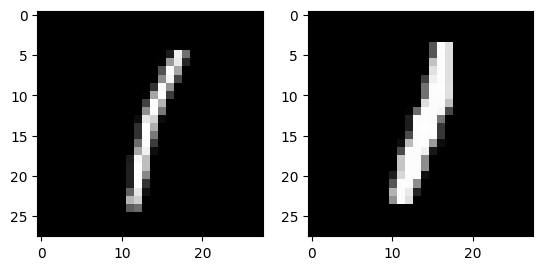

In [16]:
for pair, y in generator(X_test, y_test):
  print('Batch size:', len(y))
  idx = np.random.choice(range(len(y)))
  print(pair[0][idx].shape)
  print('Pair label:', y[idx])
  plt.subplot(121)
  plt.imshow(pair[0][idx].reshape(28, 28), cmap='gray')
  plt.subplot(122)
  plt.imshow(pair[1][idx].reshape(28, 28), cmap='gray')
  break

## **Fit model**

In [17]:
history = model.fit(generator(X_train, y_train, k=32),
                    steps_per_epoch=5,
                    epochs=500,
                    validation_data=generator(X_test, y_test, k=8),
                    validation_steps=5)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 671ms/step - loss: 0.2630 - val_loss: 0.2341
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - loss: 0.2123 - val_loss: 0.1889
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - loss: 0.1879 - val_loss: 0.1697
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - loss: 0.1627 - val_loss: 0.1593
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - loss: 0.1667 - val_loss: 0.1447
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step - loss: 0.1465 - val_loss: 0.1480
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 602ms/step - loss: 0.1492 - val_loss: 0.1391
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - loss: 0.1317 - val_loss: 0.1302
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 383ms/step - loss: 0.1365 - val_loss: 0.1269
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - loss: 0.1272 - val_loss: 0.1231
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - loss: 0.1226 - val_loss: 0.1219
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 384ms/step - loss: 0.1

## **Visualize learning process**

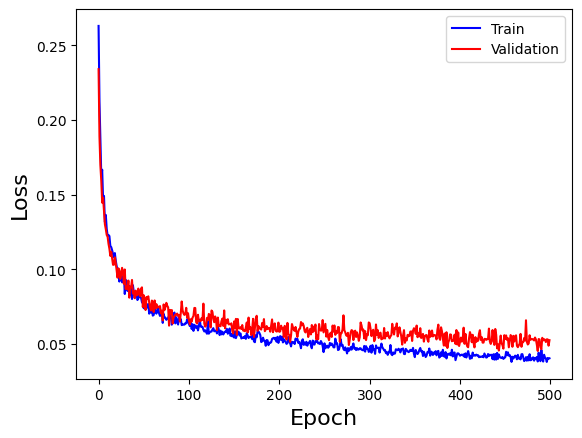

In [19]:
plt.plot(history.history['loss'], label='Train', c='b')
plt.plot(history.history['val_loss'], label='Validation', c='r')
plt.legend()
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Batch size: 160
Pair label: [1.]
Distance: [0.12295105]
Distance by feature: [0.12295114]


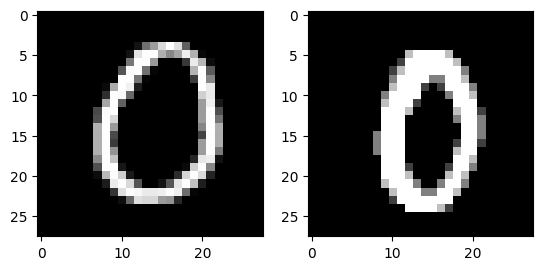

In [21]:
for pair, y in generator(X_test, y_test):
  y_pred = model.predict(pair)
  print('Batch size:', len(y))
  idx = np.random.choice(range(len(y)))
  print('Pair label:', y[idx])
  print('Distance:', y_pred[idx])

  f1 = cnn(pair[0])
  f2 = cnn(pair[1])
  d = np.sqrt(np.sum((f1-f2)**2, axis=1, keepdims=True))
  print('Distance by feature:', d[idx])

  plt.subplot(121)
  plt.imshow(pair[0][idx].reshape(28, 28), cmap='gray')
  plt.subplot(122)
  plt.imshow(pair[1][idx].reshape(28, 28), cmap='gray')
  break

## **Visualize new feature space**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


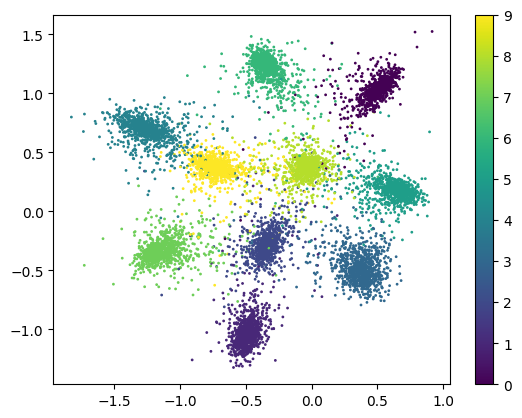

In [22]:
f = cnn.predict(X_test/255.)
p = plt.scatter(f[:, 0], f[:, 1], c=y_test, s=1)
plt.colorbar(p)

## **Save model**

In [23]:
cnn.save('cnn_loss1.h5')

## **Load model and test**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


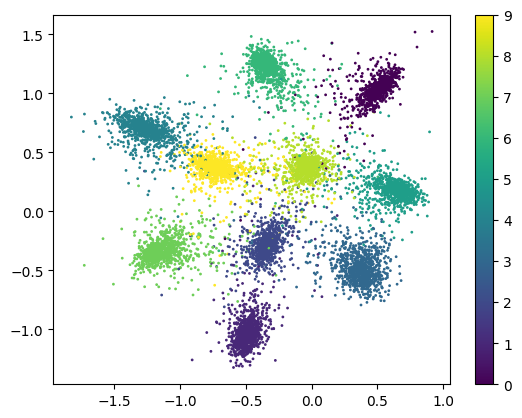

In [24]:
m = load_model('cnn_loss1.h5')
f1 = m.predict(X_test/255.)
p = plt.scatter(f1[:, 0], f1[:, 1], c=y_test, s=1)
plt.colorbar(p)

## **Visualize negative distance and positive distance**

In [25]:
i = 0
y_true = []
y_pred = []
for pair, y in generator(X_test, y_test):
  f1 = cnn(pair[0])
  f2 = cnn(pair[1])
  d = np.sqrt(np.sum((f1-f2)**2, axis=1, keepdims=True))
  y_pred += list(d.ravel())
  y_true += list(y)
  i += 1
  if i > 500:
    break

## ́**Plot histogram**

(array([9.31079789e-03, 2.87945016e-02, 7.79348268e-02, 2.01044307e-01,
        5.52613211e-01, 9.10044095e-01, 8.87284372e-01, 5.96925721e-01,
        4.87954879e-01, 6.47100587e-01, 6.94343703e-01, 4.92610279e-01,
        4.08123392e-01, 3.37085160e-01, 2.43287951e-01, 1.88112486e-01,
        1.17074590e-01, 2.70703106e-02, 3.27601946e-03, 6.89688307e-04]),
 array([0.00832059, 0.15302412, 0.29772767, 0.44243121, 0.58713472,
        0.73183823, 0.87654179, 1.02124536, 1.16594887, 1.31065238,
        1.45535588, 1.60005951, 1.74476302, 1.88946652, 2.03417015,
        2.17887354, 2.32357717, 2.46828079, 2.61298418, 2.75768781,
        2.90239143]),
 <BarContainer object of 20 artists>)

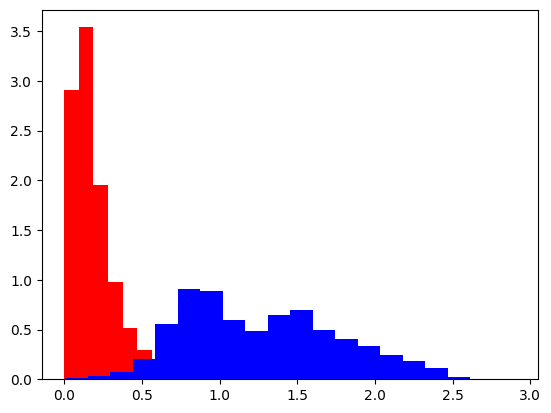

In [26]:
y_pred = np.array(y_pred)
y_true = np.array(y_true).ravel()

positive_distances = y_pred[y_true == 1]
negative_distances = y_pred[y_true == 0]

plt.hist(positive_distances, color='r', density=True, bins=20)
plt.hist(negative_distances, color='b', density=True, bins=20)

## **Check report using sklearn**

In [27]:
thresh = 0.5
y_pred_ = (y_pred < thresh)
y_pred_.astype('uint8')
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_))

              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96     40080
         1.0       0.97      0.94      0.96     40080

    accuracy                           0.96     80160
   macro avg       0.96      0.96      0.96     80160
weighted avg       0.96      0.96      0.96     80160



# **Yêu cầu 2: Xây dựng mô hình KNN để phân loại chữ số viết tay từ các feature tách được**

In [31]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

In [33]:
# Dùng model đã train để trích xuất features
X_train_features = cnn.predict(X_train_scaled, batch_size=256)
X_test_features = cnn.predict(X_test_scaled, batch_size=256)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
X_train_features.shape

(60000, 2)

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [37]:
# Khởi tạo model KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [38]:
# Train model trên tập features của train
knn.fit(X_train_features, y_train)

KNeighborsClassifier()

In [39]:
# Dự đoán trên tập features của test
y_pred_knn = knn.predict(X_test_features)

In [43]:
# Đánh giá
acc = accuracy_score(y_test, y_pred_knn)
acc

0.9572

In [45]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.92      0.95      0.93      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.96      0.95      0.96       892
           6       0.98      0.96      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.91      0.92      0.92       974
           9       0.93      0.92      0.93      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



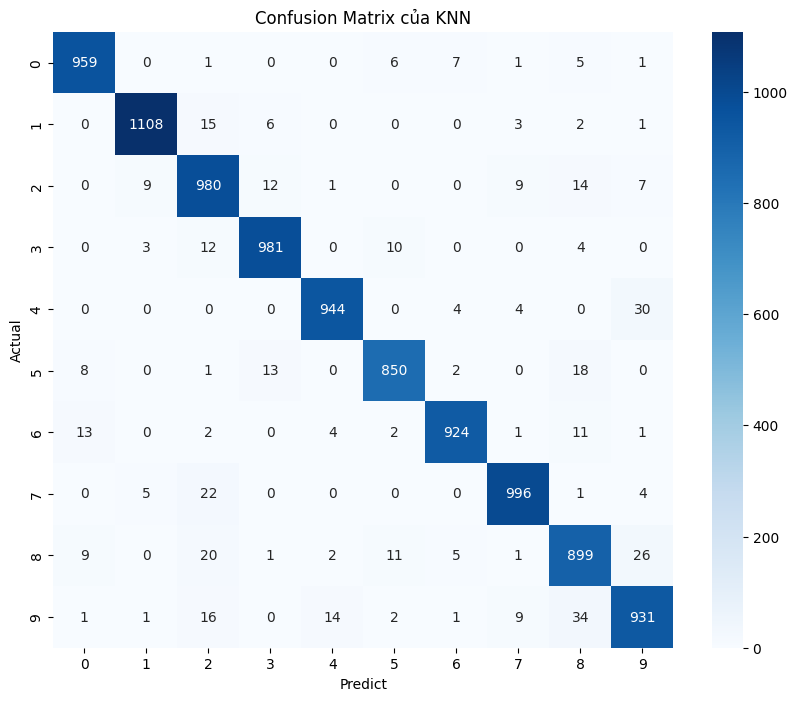

In [46]:
# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix của KNN')
plt.xlabel('Predict')
plt.ylabel('Actual')
plt.show()

In [54]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf # Not strictly needed if using np array directly

num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
  img = X_test[idx]
  true_label = y_test[idx]
  # Prepare numpy array input, ensuring float32 and batch dimension
  img_input_np = (img.reshape(1, 28, 28, 1) / 255.0).astype(np.float32)

  # Use the original 'cnn' model for prediction, as it has proven to work for batch inputs
  feature_2d = cnn.predict(img_input_np, verbose=0) # Changed 'm' to 'cnn'

  pred_label = knn.predict(feature_2d)[0]
  plt.subplot(2, 5, i + 1)
  plt.imshow(img, cmap='gray')
  color = 'green' if pred_label == true_label else 'red'
  plt.title(f"Dự đoán: {pred_label}\nThực tế: {true_label}", color=color)
  plt.axis('off')

plt.tight_layout()
plt.show()

ValueError: as_list() is not defined on an unknown TensorShape.

<Figure size 1500x500 with 0 Axes>